In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier, Pool
from sklearn.pipeline import Pipeline

In [172]:
df = pd.read_csv('/kaggle/input/datasets/samvelgalstyan/newdata/PS_20174392719_1491204439457_log.csv')

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [174]:
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

In [175]:
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1


In [176]:
df.isna().sum().sort_values(ascending=False)

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [177]:
X = df.drop('isFraud',axis=1)
y = df['isFraud']

In [178]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [179]:
str_cols_train = X_train.select_dtypes('object').columns.tolist()

In [180]:
pool_data_train = Pool(X_train,y_train, cat_features=str_cols_train)
pool_data_test = Pool(X_test,y_test, cat_features=str_cols_train)

In [181]:
model = CatBoostClassifier(iterations=300,depth=6,learning_rate=0.01,thread_count=-1,eval_metric='AUC', bootstrap_type='Bernoulli')

In [182]:
model.fit(pool_data_train, verbose=0)

CatBoostClassifier(bootstrap_type='Bernoulli', depth=6, eval_metric='AUC', iterations=300, learning_rate=0.01)

In [183]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

In [186]:
y_pred_proba = model.predict_proba(X_test)[:,1]

In [218]:
precision, recall, threshold = precision_recall_curve(y_test,y_pred_proba)
ind = np.where(precision[:-1] >= 0.8)[0]
best_threshold = threshold[ind][0]


In [207]:
y_pred = (y_pred_proba >= best_threshold).astype(int)

In [208]:
roc_auc_score(y_test, y_pred)

np.float64(0.8998725316782386)

In [209]:
confusion_matrix(y_test,y_pred)

array([[1270580,     324],
       [    324,    1296]])

In [210]:
print(classification_report(y_test,y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997   1270904
           1     0.8000    0.8000    0.8000      1620

    accuracy                         0.9995   1272524
   macro avg     0.8999    0.8999    0.8999   1272524
weighted avg     0.9995    0.9995    0.9995   1272524



(0.0, 1.1)

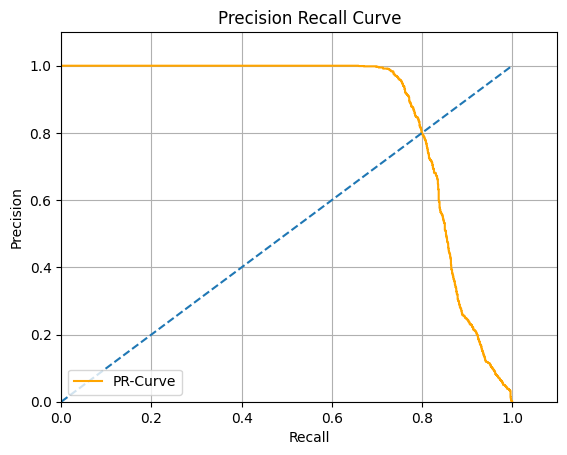

In [221]:
plt.plot(recall, precision, color='orange', label='PR-Curve')
plt.plot([0,1],[0,1], linestyle='dashed')
plt.title('Precision Recall Curve')
plt.legend(loc='lower left')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.xlim(0,1.1)
plt.ylim(0,1.1)

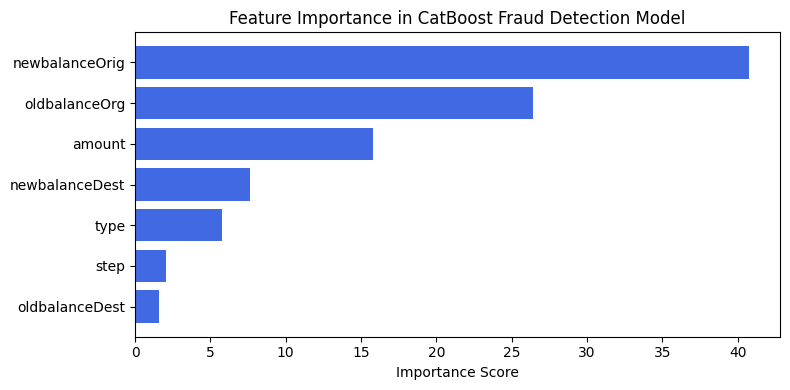

In [222]:
importance = model.get_feature_importance()
indices = np.argsort(importance)[::-1]
plt.figure(figsize=(8, 4))
plt.title("Feature Importance in CatBoost Fraud Detection Model")
plt.barh(range(len(indices)), importance[indices], align="center", color="royalblue")
plt.yticks(range(len(indices)), X_train.columns[indices])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.tight_layout()

In [217]:
model.save_model("fraud_catboost_model.cbm")